<a href="https://colab.research.google.com/github/workshahnawaz643-tech/ShahFAML/blob/main/PMC1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Original Dataset Shape: (33, 11)
Expanded Dataset Shape: (2033, 8)

MODEL PERFORMANCE

Linear Regression
R2 Score: 0.7712087684373993
RMSE: 2.1512610095977336
---------------------
Random Forest
R2 Score: 0.9993963214698701
RMSE: 0.1102672836686783
---------------------
Support Vector Machine
R2 Score: 0.8114215610808753
RMSE: 2.1626007188537684
---------------------
Gaussian Process
R2 Score: 0.9976518320225433
RMSE: 0.19981321988672965
---------------------
Gradient Boosting
R2 Score: 0.9997189547438351
RMSE: 0.07028750085555181
---------------------
Neural Network
R2 Score: 0.9974429318964878
RMSE: 0.21315106068592446
---------------------

BEST MODEL: Gradient Boosting
BEST R2 SCORE: 0.9997189547438351


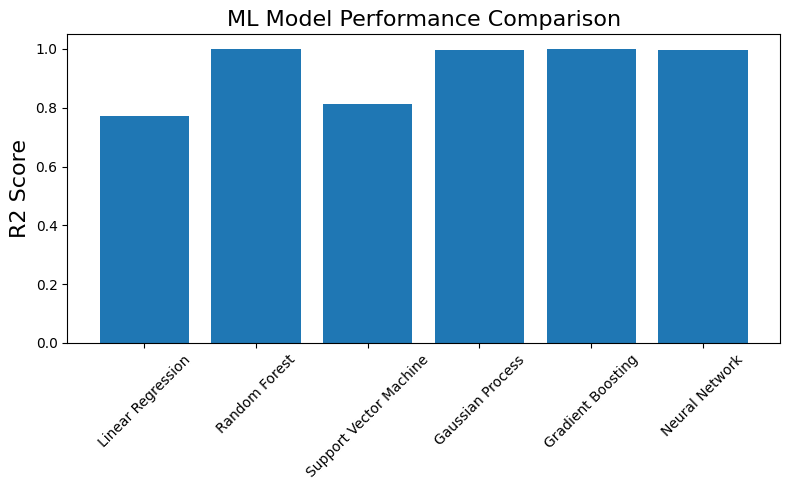

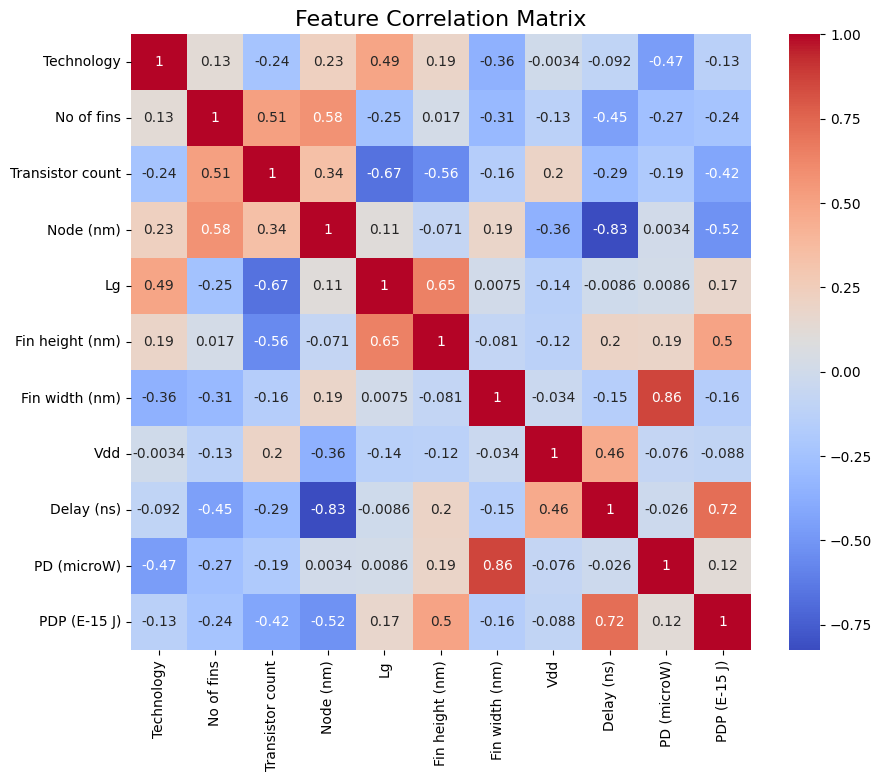

<Figure size 800x400 with 0 Axes>

<Figure size 800x400 with 0 Axes>

In [2]:
# FINFET FULL ADDER ML MODEL

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error

# ML MODELS
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.multioutput import MultiOutputRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import GradientBoostingRegressor


# LOAD DATASET

data = pd.read_csv("https://raw.githubusercontent.com/workshahnawaz643-tech/ShahFAML/refs/heads/main/Dataset1-3.csv")

print("Original Dataset Shape:", data.shape)


# DATA CLEANING AND PREPROCESSING

data = data.dropna()

data['Technology'] = data['Technology'].astype('category').cat.codes


X = data.drop(columns=['Delay (ns)','PD (microW)','PDP (E-15 J)'])

y = data[['Delay (ns)','PD (microW)','PDP (E-15 J)']]


# MONTE CARLO DATASET EXPANSION


def monte_carlo_expand(X, y, n_samples=1000, noise=0.05):

    X_new = []
    y_new = []

    for i in range(n_samples):

        idx = np.random.randint(0,len(X))

        x = X.iloc[idx].values
        target = y.iloc[idx].values

        # Add Gaussian noise
        x_new = x + np.random.uniform(0, noise*np.std(X.values,axis=0))
        y_new_val = target + np.random.uniform(0, noise*np.std(y.values,axis=0))

        X_new.append(x_new)
        y_new.append(y_new_val)

    X_new = np.array(X_new)
    y_new = np.array(y_new)

    X_expanded = np.vstack([X.values, X_new])
    y_expanded = np.vstack([y.values, y_new])

    return X_expanded, y_expanded


X_expanded, y_expanded = monte_carlo_expand(X,y,2000)

print("Expanded Dataset Shape:",X_expanded.shape)


#  ML Model TRAIN and TEST

X_train, X_test, y_train, y_test = train_test_split(
    X_expanded,
    y_expanded,
    test_size=0.2,
    random_state=42
)


scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


#  ML MODELS


models = {

"Linear Regression":
MultiOutputRegressor(LinearRegression()),

"Random Forest":
RandomForestRegressor(
n_estimators=300,
max_depth=12,
random_state=42
),

"Support Vector Machine":
MultiOutputRegressor(
SVR(kernel='rbf',C=10)
),

"Gaussian Process":
MultiOutputRegressor(
GaussianProcessRegressor()
),

"Gradient Boosting":
MultiOutputRegressor(
GradientBoostingRegressor()
),

"Neural Network":
MLPRegressor(
hidden_layer_sizes=(100,100),
max_iter=2000
)

}

# ML MODEL TRAINING AND COMPARISON


results = {}

print("\nMODEL PERFORMANCE\n")

for name,model in models.items():

    model.fit(X_train,y_train)

    pred = model.predict(X_test)

    r2 = r2_score(y_test,pred)

    rmse = np.sqrt(mean_squared_error(y_test,pred))

    results[name] = r2

    print(name)
    print("R2 Score:",r2)
    print("RMSE:",rmse)
    print("---------------------")


best_model = max(results,key=results.get)

print("\nBEST MODEL:",best_model)
print("BEST R2 SCORE:",results[best_model])

plt.figure(figsize=(8,5))

names = list(results.keys())
scores = list(results.values())

plt.bar(names, scores)

plt.ylabel("R2 Score",fontsize=16)
plt.title("ML Model Performance Comparison",fontsize=16)

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

pred_best = models[best_model].predict(X_test)

import seaborn as sns

plt.figure(figsize=(10,8))

sns.heatmap(data.corr(), annot=True, cmap='coolwarm')

plt.title("Feature Correlation Matrix",fontsize=16)

plt.show()

error = abs(y_test[:,0] - pred_best[:,0])

plt.figure(figsize=(8,4))






